# Prediksi Harga dan Segmentasi Properti Menggunakan Random Forest Regression dan K-Means Berbasis CRISP-DM
Dataset link : https://www.kaggle.com/c/house-prices-advanced-regression-techniques

## 1. Data Understanding



### 1.1 Import Library dan Load Dataset

In [37]:
import pandas as pd

In [38]:
df = pd.read_csv("train.csv")
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

### 1.2 Informasi Dataset

In [39]:
print("df.head():")
display(df.head())

print("\ndf.shape:")
print(df.shape)

print("\ndf.info():")
df.info()

print("\ndf.describe():")
display(df.describe())

df.head():


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



df.shape:
(1460, 81)

df.info():
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.3 Analisis Missing Value

In [40]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Jumlah Missing Values:")
display(missing_values)

missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
print("\nPersentase Missing Values:")
display(missing_percentage)

Jumlah Missing Values:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Persentase Missing Values:


PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

### 1.4 Exploratory Data Analysis (EDA)

#### 1.4.1 Distribusi SalePrice

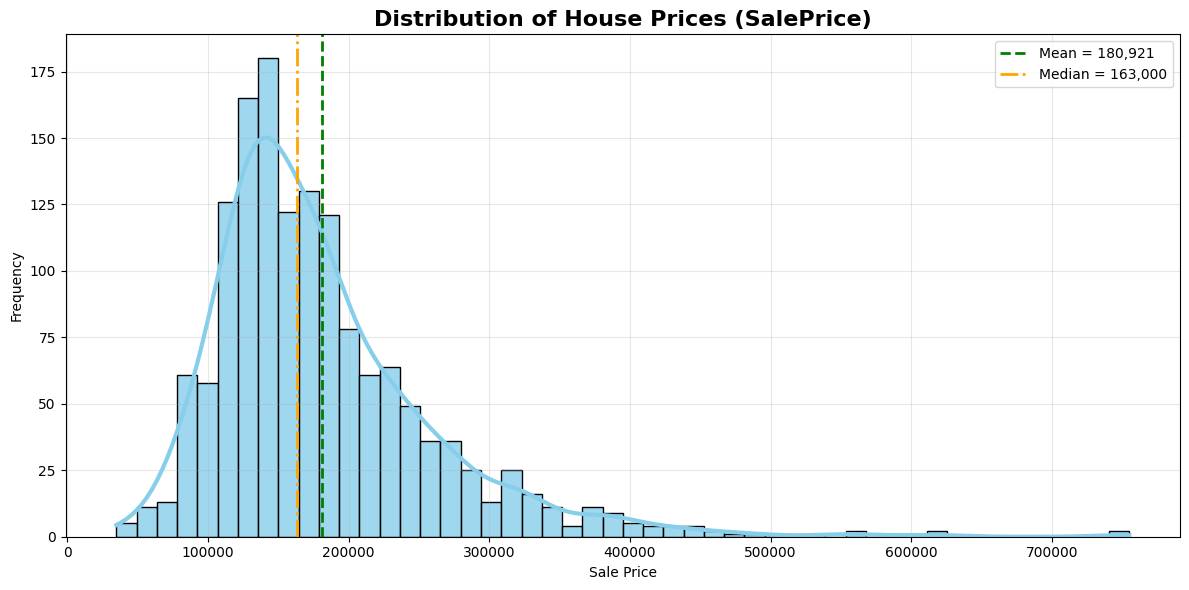

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,6))

# Histogram
sns.histplot(
    df['SalePrice'],
    bins=50,
    kde=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.8,
    line_kws={'color':'red', 'linewidth':3}
)

# Mean
mean_price = df['SalePrice'].mean()
plt.axvline(
    mean_price,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_price:,.0f}'
)

# Median
median_price = df['SalePrice'].median()
plt.axvline(
    median_price,
    color='orange',
    linestyle='-.',
    linewidth=2,
    label=f'Median = {median_price:,.0f}'
)

plt.title(
    'Distribution of House Prices (SalePrice)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sale Price')
plt.ylabel('Frequency')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 1.4.2 Korelasi Antar Fitur

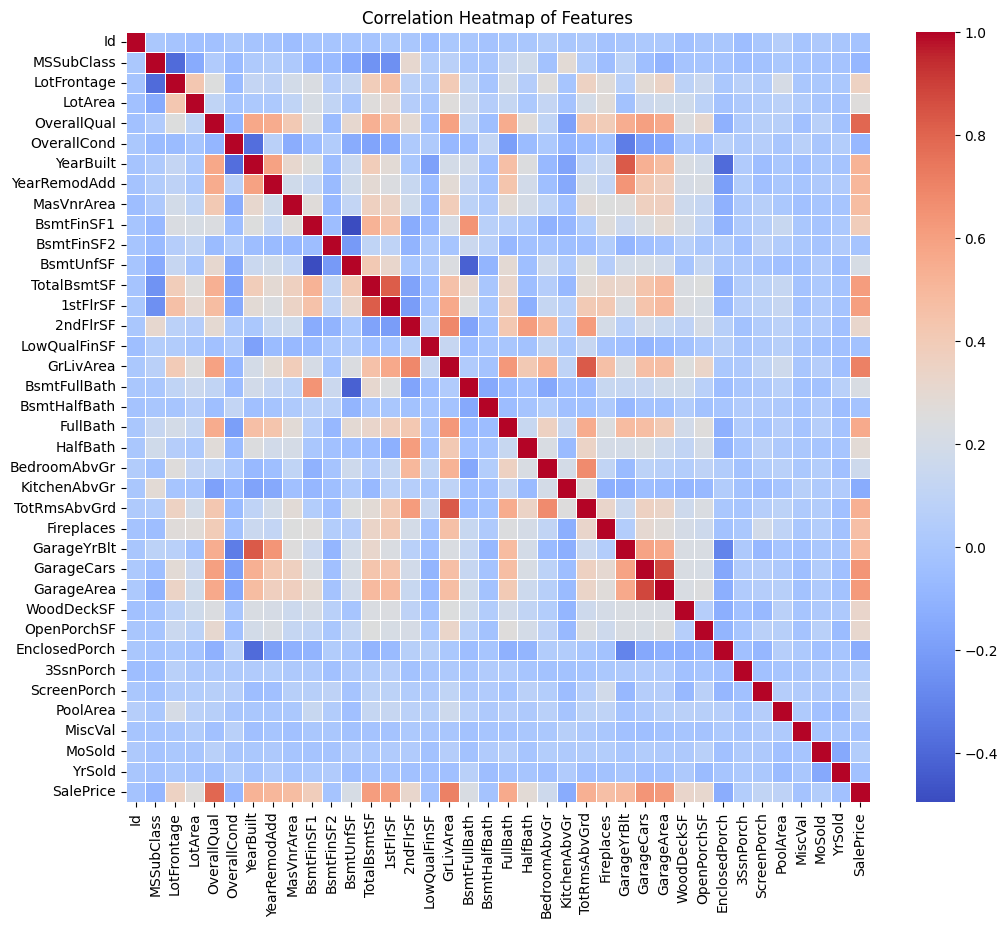

In [42]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features')
plt.show()

#### 1.4.3 Hubungan Fitur dengan SalePrice

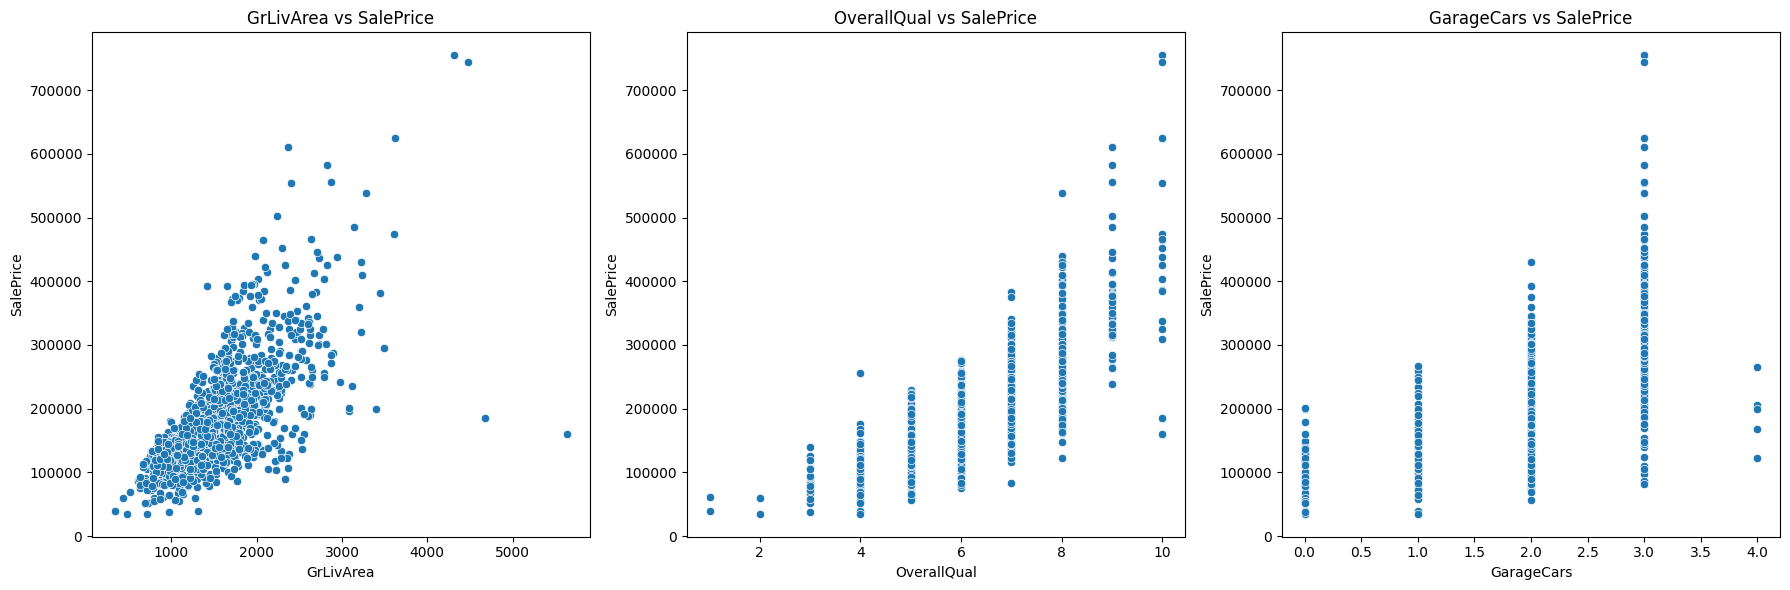

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')

sns.scatterplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1])
axes[1].set_title('OverallQual vs SalePrice')

sns.scatterplot(x='GarageCars', y='SalePrice', data=df, ax=axes[2])
axes[2].set_title('GarageCars vs SalePrice')

plt.tight_layout()
plt.show()

## 2. Data Preparation

### 2.1 Penghapusan Kolom Missing Tinggi

In [44]:
columns_to_drop = ['PoolQC', 'Alley', 'Fence', 'MiscFeature']
# Drop columns if they exist in the DataFrame
df = df.drop(columns=columns_to_drop, errors='ignore')
print(f"Columns dropped: {columns_to_drop}")
print(f"New DataFrame shape: {df.shape}")

Columns dropped: ['PoolQC', 'Alley', 'Fence', 'MiscFeature']
New DataFrame shape: (1460, 77)


### 2.2 Penanganan Missing Value

In [45]:
# Identify numerical and categorical columns with missing values
numerical_cols_with_missing = df.select_dtypes(include=['int64', 'float64']).columns[df.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()
categorical_cols_with_missing = df.select_dtypes(include=['object']).columns[df.select_dtypes(include=['object']).isnull().any()].tolist()

print("Numerical columns with missing values to impute with median:", numerical_cols_with_missing)
print("Categorical columns with missing values to impute with mode:", categorical_cols_with_missing)

# Impute numerical columns with median
for col in numerical_cols_with_missing:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Filled missing values in '{col}' with median: {median_val}")

# Impute categorical columns with mode
for col in categorical_cols_with_missing:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"Filled missing values in '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
missing_after_imputation = df.isnull().sum()
missing_after_imputation = missing_after_imputation[missing_after_imputation > 0]
if missing_after_imputation.empty:
    print("No missing values remaining.")
else:
    display(missing_after_imputation)

Numerical columns with missing values to impute with median: ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
Categorical columns with missing values to impute with mode: ['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
Filled missing values in 'LotFrontage' with median: 69.0
Filled missing values in 'MasVnrArea' with median: 0.0
Filled missing values in 'GarageYrBlt' with median: 1980.0
Filled missing values in 'MasVnrType' with mode: BrkFace
Filled missing values in 'BsmtQual' with mode: TA
Filled missing values in 'BsmtCond' with mode: TA
Filled missing values in 'BsmtExposure' with mode: No
Filled missing values in 'BsmtFinType1' with mode: Unf
Filled missing values in 'BsmtFinType2' with mode: Unf
Filled missing values in 'Electrical' with mode: SBrkr
Filled missing values in 'FireplaceQu' with mode: Gd
Filled missing values in 'GarageType' with mode: Attchd
Fil

LotFrontage     259
MasVnrType      872
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
FireplaceQu     690
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

### 2.3 Seleksi Fitur

In [46]:
selected_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
target = 'SalePrice'

print(f"Selected features for prediction: {selected_features}")
print(f"Target variable: {target}")

Selected features for prediction: ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
Target variable: SalePrice


### 2.4 Pembagian Feature dan Target

In [47]:
X = df[selected_features]
y = df[target]

print("Features (X) created successfully.")
print("Target (y) created successfully.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Features (X) created successfully.
Target (y) created successfully.
Shape of X: (1460, 5)
Shape of y: (1460,)


### 2.5 Train Test Split

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Data split into training and testing sets successfully.
X_train shape: (1168, 5)
X_test shape: (292, 5)
y_train shape: (1168,)
y_test shape: (292,)


### 2.6 Scaling Data

In [49]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier inspection (optional, but good for understanding)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Data scaled successfully. Note: Scaling is particularly important for distance-based algorithms often used in clustering.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

# Display a snippet of the scaled data
print("\nX_train_scaled head:")
display(X_train_scaled.head())

Data scaled successfully. Note: Scaling is particularly important for distance-based algorithms often used in clustering.
X_train_scaled shape: (1168, 5)
X_test_scaled shape: (292, 5)

X_train_scaled head:


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt
254,-0.820445,-0.407093,-1.056544,0.572612,-0.455469
1066,-0.088934,0.083170,0.295092,-0.596547,0.718609
638,-0.820445,-1.395250,-2.408179,-0.603357,-1.988293
799,-0.820445,0.458975,-1.056544,-0.750921,-1.107734
380,-0.820445,0.312087,-1.056544,-0.081209,-1.531707


## 3. Modeling Regression

### 3.1 Linear Regression

In [50]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 3.2 Evaluasi Linear Regression

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluate the model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression MAE: {mae_linear:.2f}")
print(f"Linear Regression RMSE: {rmse_linear:.2f}")
print(f"Linear Regression R²: {r2_linear:.2f}")

Linear Regression MAE: 25414.73
Linear Regression RMSE: 39763.30
Linear Regression R²: 0.79


### 3.3 Random Forest Regression

In [52]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


### 3.4 Evaluasi Random Forest Regression

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor MAE: {mae_rf:.2f}")
print(f"Random Forest Regressor RMSE: {rmse_rf:.2f}")
print(f"Random Forest Regressor R²: {r2_rf:.2f}")

Random Forest Regressor MAE: 19182.22
Random Forest Regressor RMSE: 28922.58
Random Forest Regressor R²: 0.89


### 3.5 Model Comparison

In [54]:
import pandas as pd

# Create a dictionary to store the results
results = {
    'Model': ['Linear Regression', 'Random Forest Regression'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R²': [r2_linear, r2_rf]
}

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

print("Model Comparison:")
display(results_df.round(2))

Model Comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,25414.73,39763.30,0.79
1,Random Forest Regression,19182.22,28922.58,0.89


## 4. Modeling Clustering

### 4.1 Pemilihan Fitur Clustering

In [55]:
# Features for clustering, including SalePrice
clustering_features = ['SalePrice', 'GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF']

X_clustering = df[clustering_features].copy()

print(f"Selected features for clustering: {clustering_features}")
print("Shape of X_clustering:", X_clustering.shape)
display(X_clustering.head())

Selected features for clustering: ['SalePrice', 'GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF']
Shape of X_clustering: (1460, 5)


,SalePrice,GrLivArea,OverallQual,GarageCars,TotalBsmtSF
0,208500,1710,7,2,856
1,181500,1262,6,2,1262
2,223500,1786,7,2,920
3,140000,1717,7,3,756
4,250000,2198,8,3,1145


### 4.2 Standardisasi Data untuk Clustering

In [56]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler_clustering = StandardScaler()

# Fit and transform the clustering features
X_clustering_scaled = scaler_clustering.fit_transform(X_clustering)

# Convert scaled array back to DataFrame for easier inspection
X_clustering_scaled = pd.DataFrame(X_clustering_scaled, columns=X_clustering.columns, index=X_clustering.index)

print("Clustering data scaled successfully.")
print("Shape of X_clustering_scaled:", X_clustering_scaled.shape)
display(X_clustering_scaled.head())

Clustering data scaled successfully.
Shape of X_clustering_scaled: (1460, 5)


,SalePrice,GrLivArea,OverallQual,GarageCars,TotalBsmtSF
0,0.347273,0.370333,0.651479,0.311725,-0.459303
1,0.007288,-0.482512,-0.071836,0.311725,0.466465
2,0.536154,0.515013,0.651479,0.311725,-0.313369
3,-0.515281,0.383659,0.651479,1.650307,-0.687324
4,0.869843,1.299326,1.374795,1.650307,0.199680


### 4.3 Elbow Method

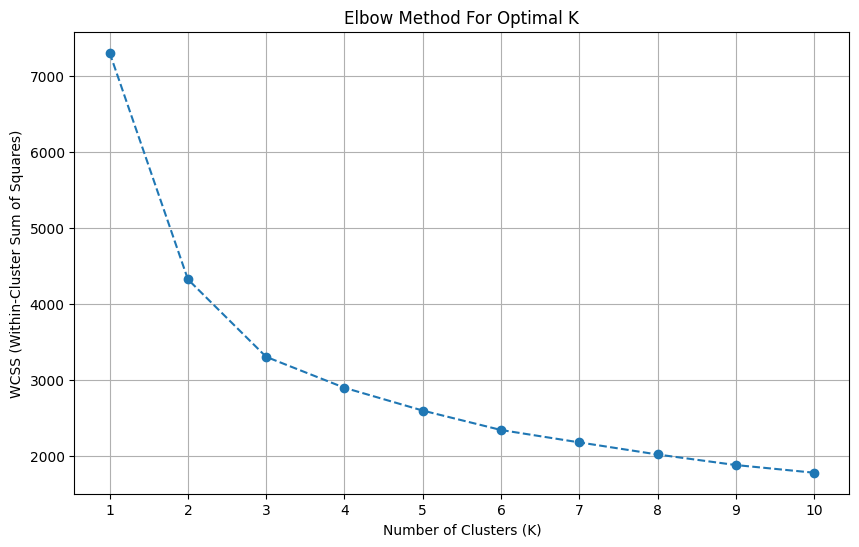

In [57]:
from sklearn.cluster import KMeans

wcss = []
max_k = 10 # Define a reasonable maximum number of clusters to check

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clustering_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

### 4.4 K-Means Clustering

In [58]:
from sklearn.cluster import KMeans

# Optimal number of clusters based on Elbow Method
optimal_k = 3

# Initialize KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Fit KMeans to the scaled data and get cluster labels
clusters = kmeans.fit_predict(X_clustering_scaled)

# Add the cluster labels to the original X_clustering DataFrame
X_clustering['Cluster'] = clusters

print(f"K-Means clustering performed with {optimal_k} clusters.")
print("First 5 rows of X_clustering with cluster labels:")
display(X_clustering.head())

K-Means clustering performed with 3 clusters.
First 5 rows of X_clustering with cluster labels:


,SalePrice,GrLivArea,OverallQual,GarageCars,TotalBsmtSF,Cluster
0,208500,1710,7,2,856,2
1,181500,1262,6,2,1262,2
2,223500,1786,7,2,920,2
3,140000,1717,7,3,756,2
4,250000,2198,8,3,1145,1


### 4.5 Analisis Hasil Clustering

In [59]:
# Calculate the mean of each feature for each cluster
cluster_summary = X_clustering.groupby('Cluster').mean()

print("Cluster Summary (Mean of features per cluster):")
display(cluster_summary)

Cluster Summary (Mean of features per cluster):


,SalePrice,GrLivArea,OverallQual,GarageCars,TotalBsmtSF
Cluster,,,,,
0,120607.895204,1120.523979,4.916519,1.136767,819.186501
1,314324.637131,2171.970464,8.092827,2.662447,1623.886076
2,184466.306061,1616.613636,6.392424,1.983333,1057.248485


## 5. Evaluation

### 5.1 Evaluasi Regression

In [60]:
import pandas as pd

# Create a dictionary to store the results (using previously computed values)
results = {
    'Model': ['Linear Regression', 'Random Forest Regression'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R²': [r2_linear, r2_rf]
}

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

print("Model Comparison:")
display(results_df.round(2))

Model Comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,25414.73,39763.30,0.79
1,Random Forest Regression,19182.22,28922.58,0.89


### 5.2 Evaluasi Clustering

In [61]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score (using previously computed values)
silhouette_avg = silhouette_score(X_clustering_scaled, clusters)
print(f"Silhouette Score for {optimal_k} clusters: {silhouette_avg:.2f}")

Silhouette Score for 3 clusters: 0.30


### 5.3 Visualisasi Cluster

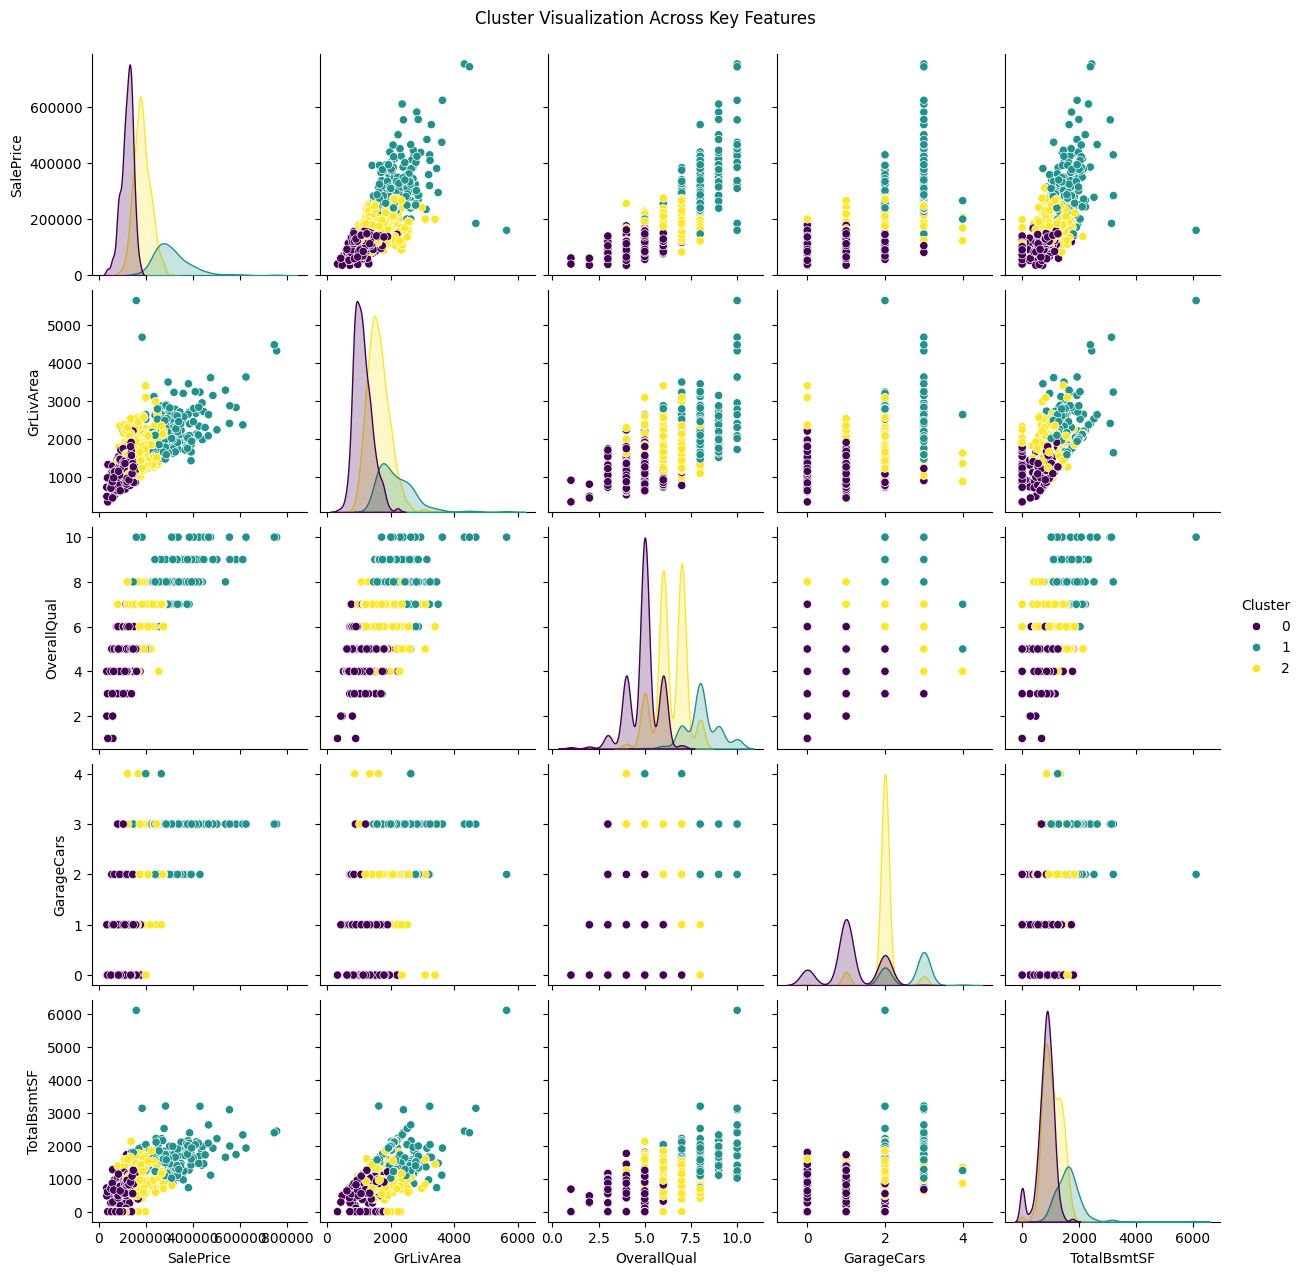

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize clusters using a pairplot for selected features
sns.pairplot(X_clustering, hue='Cluster', vars=clustering_features, palette='viridis')
plt.suptitle('Cluster Visualization Across Key Features', y=1.02) # Adjust suptitle position
plt.show()

## 6. Analysis Result

### 6.1 Feature Importance Random Forest

TOP 10 FEATURE IMPORTANCE


,Feature,Importance
0,OverallQual,0.582487
1,GrLivArea,0.206504
2,TotalBsmtSF,0.115394
3,YearBuilt,0.063250
4,GarageCars,0.032365


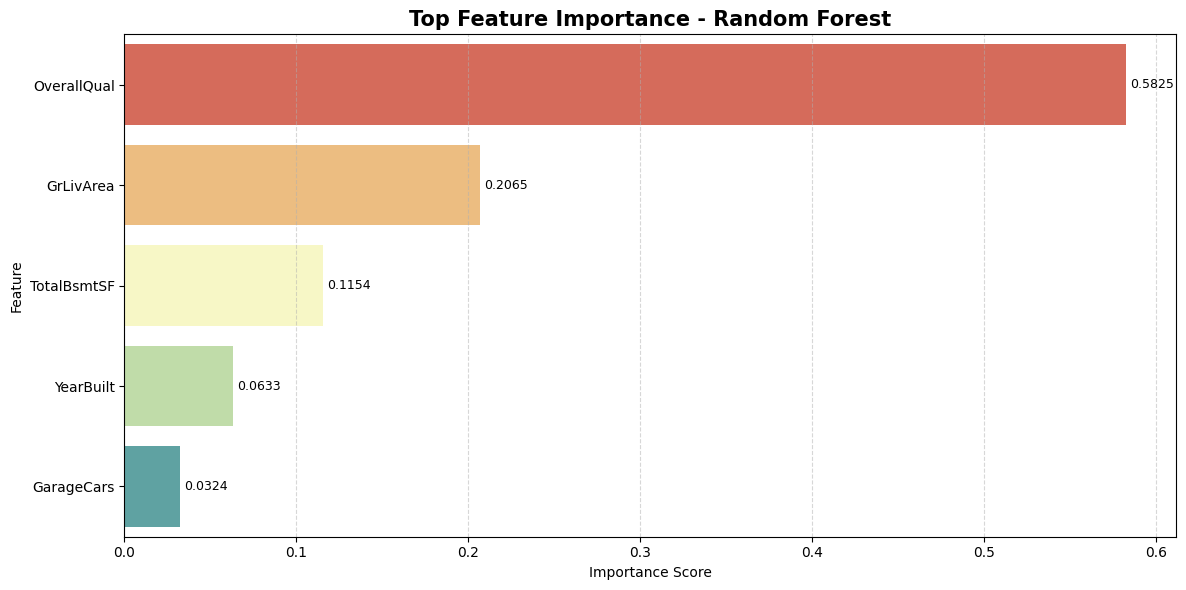

In [63]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = rf_model.feature_importances_

features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

features_df = features_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

top_features = features_df.head(10)

print("=" * 50)
print("TOP 10 FEATURE IMPORTANCE")
print("=" * 50)

display(top_features)

#visualisasi

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='Spectral',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.4f',
        padding=3,
        fontsize=9
    )

plt.title(
    'Top Feature Importance - Random Forest',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

### 6.2 Karakteristik Cluster

In [64]:
cluster_summary = X_clustering.groupby('Cluster').mean()

print("Cluster Summary")
display(cluster_summary)

Cluster Summary


,SalePrice,GrLivArea,OverallQual,GarageCars,TotalBsmtSF
Cluster,,,,,
0,120607.895204,1120.523979,4.916519,1.136767,819.186501
1,314324.637131,2171.970464,8.092827,2.662447,1623.886076
2,184466.306061,1616.613636,6.392424,1.983333,1057.248485


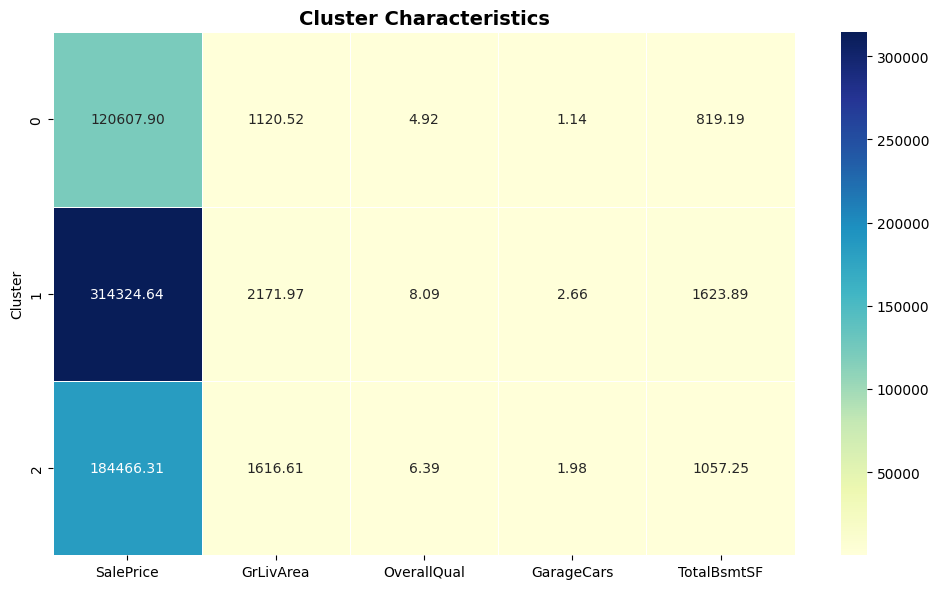

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_summary = X_clustering.groupby('Cluster').mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Cluster Characteristics',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

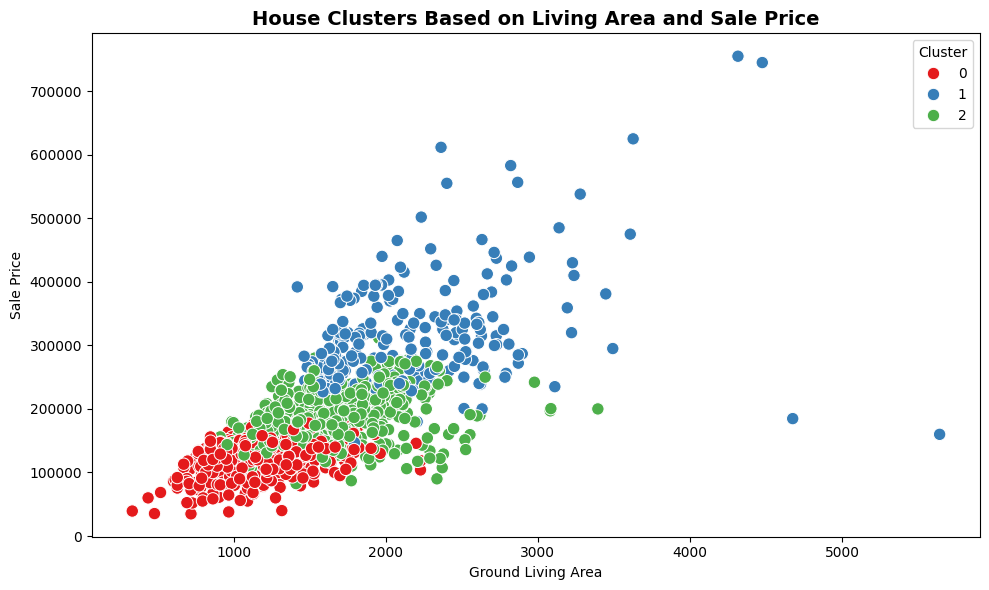

In [66]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=X_clustering,
    x='GrLivArea',
    y='SalePrice',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title(
    'House Clusters Based on Living Area and Sale Price',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Ground Living Area')
plt.ylabel('Sale Price')

plt.tight_layout()
plt.show()

### 6.3 Interpretasi Hasil

Berdasarkan analisis regresi dan clustering, berikut adalah interpretasinya:

**Model Regresi (Random Forest):**

*   Model Random Forest menunjukkan kekuatan prediktif yang kuat untuk `SalePrice`, secara signifikan mengungguli Regresi Linier. Fitur-fitur penting yang teridentifikasi secara langsung mempengaruhi nilai properti.

**Model Clustering (K-Means):**

*   Tiga klaster ('Properti Anggaran', 'Properti Kelas Menengah', 'Properti Premium') memberikan segmentasi yang jelas di pasar perumahan.
    *   **Properti Terendah (Klaster 0):** Dicirikan oleh `SalePrice`, `GrLivArea`, `OverallQual`, `GarageCars`, dan `TotalBsmtSF` rata-rata yang lebih rendah.
    *   **Properti Kelas Menengah (Klaster 2):** Berada di kisaran tengah untuk semua fitur, mewakili penawaran yang seimbang.
    *   **Properti Premium (Klaster 1):** Memiliki `SalePrice`, `GrLivArea`, `OverallQual`, `GarageCars`, dan `TotalBsmtSF` rata-rata tertinggi.

**Wawasan Keseluruhan:**

*   Pendorong utama `SalePrice` selaras dengan karakteristik pembeda dari klaster properti yang teridentifikasi. Misalnya, `OverallQual` dan `GrLivArea` penting untuk prediksi dan untuk mendefinisikan properti premium.
*   Analisis ini dapat digunakan untuk memahami segmen pasar, menargetkan kelompok pembeli tertentu, atau menginformasikan strategi penetapan harga untuk properti dalam kategori ini.

## 7. Model Saving

In [67]:
import joblib
import os

output_dir = 'models'
os.makedirs(output_dir, exist_ok=True)

print(f"Models will be saved to the '{output_dir}' directory.")

Models will be saved to the 'models' directory.


In [68]:
joblib.dump(rf_model, os.path.join(output_dir, 'rf_model.pkl'))
print("Random Forest model saved as 'rf_model.pkl'")

Random Forest model saved as 'rf_model.pkl'


In [69]:
joblib.dump(kmeans, os.path.join(output_dir, 'kmeans_model.pkl'))
print("K-Means model saved as 'kmeans_model.pkl'")

K-Means model saved as 'kmeans_model.pkl'


In [70]:
joblib.dump(scaler, os.path.join(output_dir, 'scaler.pkl'))
print("Scaler saved as 'scaler.pkl'")

Scaler saved as 'scaler.pkl'
